## Join clusters and annotations with optimal analysis

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

In [37]:
region = 'cerebral_cortex' # Options: 'cerebral_cortex', 'hippocampus'
rev_n = 12 # Use 12
input_path = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_optimal{rev_n}.h5ad"
adata = sc.read_h5ad(input_path)


## get clusters from `subcluster.ipynb`

In [ ]:
clusters =pd.read_csv(f"../results/{region}_recursive_hpo_subclustering_labels.csv", index_col=0)
adata.obs['supercluster'] = clusters['supercluster'].astype('category')
adata.obs['cluster'] = clusters['cluster']
adata.obs['subcluster'] = clusters['subcluster']

In [39]:
print(f'Number of superclusters: {clusters['supercluster'].nunique()}')
print(f'Number of clusters: {clusters['cluster'].nunique()}')   
print(f'Number of subclusters: {clusters['subcluster'].nunique()}')

Number of superclusters: 4
Number of clusters: 28
Number of subclusters: 50


In [40]:
adata

AnnData object with n_obs × n_vars = 24378 × 17413
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'leiden_1.0', 'leiden_5.0', 'supercluster', 'cluster', 'subcluster'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'is_highly_variable'
    uns: 'hvg',

In [29]:
# Search for a specific gene in adata.var (insensitive to case)
adata.var[adata.var_names.str.contains('ELAVL4', case=False)]


,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,mean,std,is_highly_variable
ELAVL4,False,False,2560,0.290895,0.255336,82.111662,4163.0,8.334231,2518,True,743.0,0.296098,0.620528,1.390233,2,0.298445,0.695147,True


In [30]:
celltypes = pd.read_csv(f'/home/ratopin/nakedmolerat-scRNAseq/annotation/class_score_annotation/{region}_cadums_predictions.csv', index_col=0)
celltypes.head()

,cadums_pred_subcluster
AAACCCAAGCCGTTGC-1-NMR3,Granular Neuron
AAACCCAAGGTTACAA-1-NMR3,LGE Interneuron
AAACCCAAGTCTGCGC-1-NMR3,Neuroblast
AAACCCACAAACACCT-1-NMR3,Pyramidal Neuron
AAACCCAGTGGTCTTA-1-NMR3,Microglia


In [31]:
adata.obs['celltype'] = adata.obs_names.map(celltypes['cadums_pred_subcluster'])

In [32]:
adata.obs['celltype'] 

AAACCCAAGCCGTTGC-1-NMR3                      Granular Neuron
AAACCCAAGGTTACAA-1-NMR3                      LGE Interneuron
AAACCCAAGTCTGCGC-1-NMR3                           Neuroblast
AAACCCACAAACACCT-1-NMR3                     Pyramidal Neuron
AAACCCAGTGGTCTTA-1-NMR3                            Microglia
                                         ...                
TTTGTTGCAGGACAGT-1-NMR4                     Pyramidal Neuron
TTTGTTGGTCATCACA-1-NMR4                     Pyramidal Neuron
TTTGTTGGTTCCGTTC-1-NMR4                     CGE Interneuron*
TTTGTTGTCCAGTTCC-1-NMR4    LGE Interneuron | MGE Interneuron
TTTGTTGTCCTACGGG-1-NMR4                      Granular Neuron
Name: celltype, Length: 13634, dtype: object

In [33]:
adata

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'leiden_1.0', 'leiden_5.0', 'supercluster', 'cluster', 'subcluster', 'celltype'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'is_highly_variable'
   

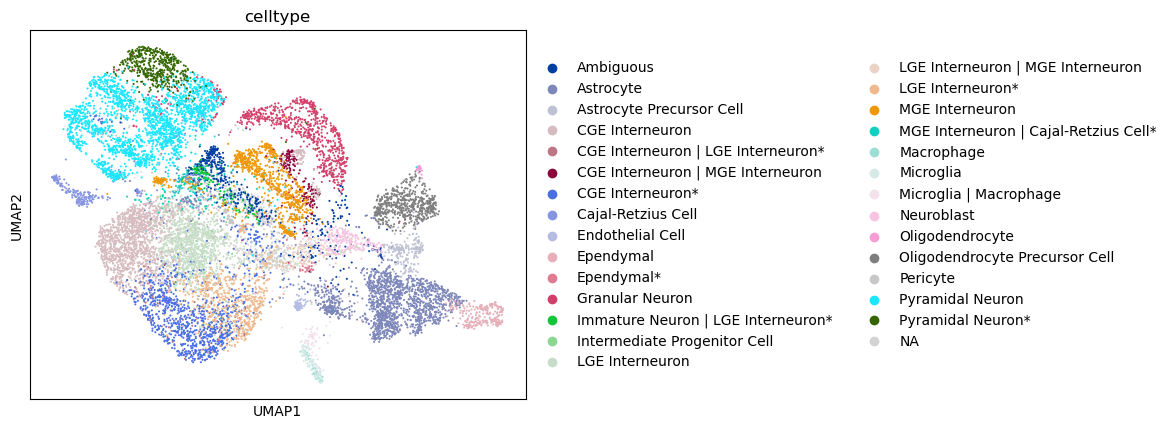

In [34]:
sc.pl.umap(adata, color=['celltype'], wspace=0.5, ncols=2)

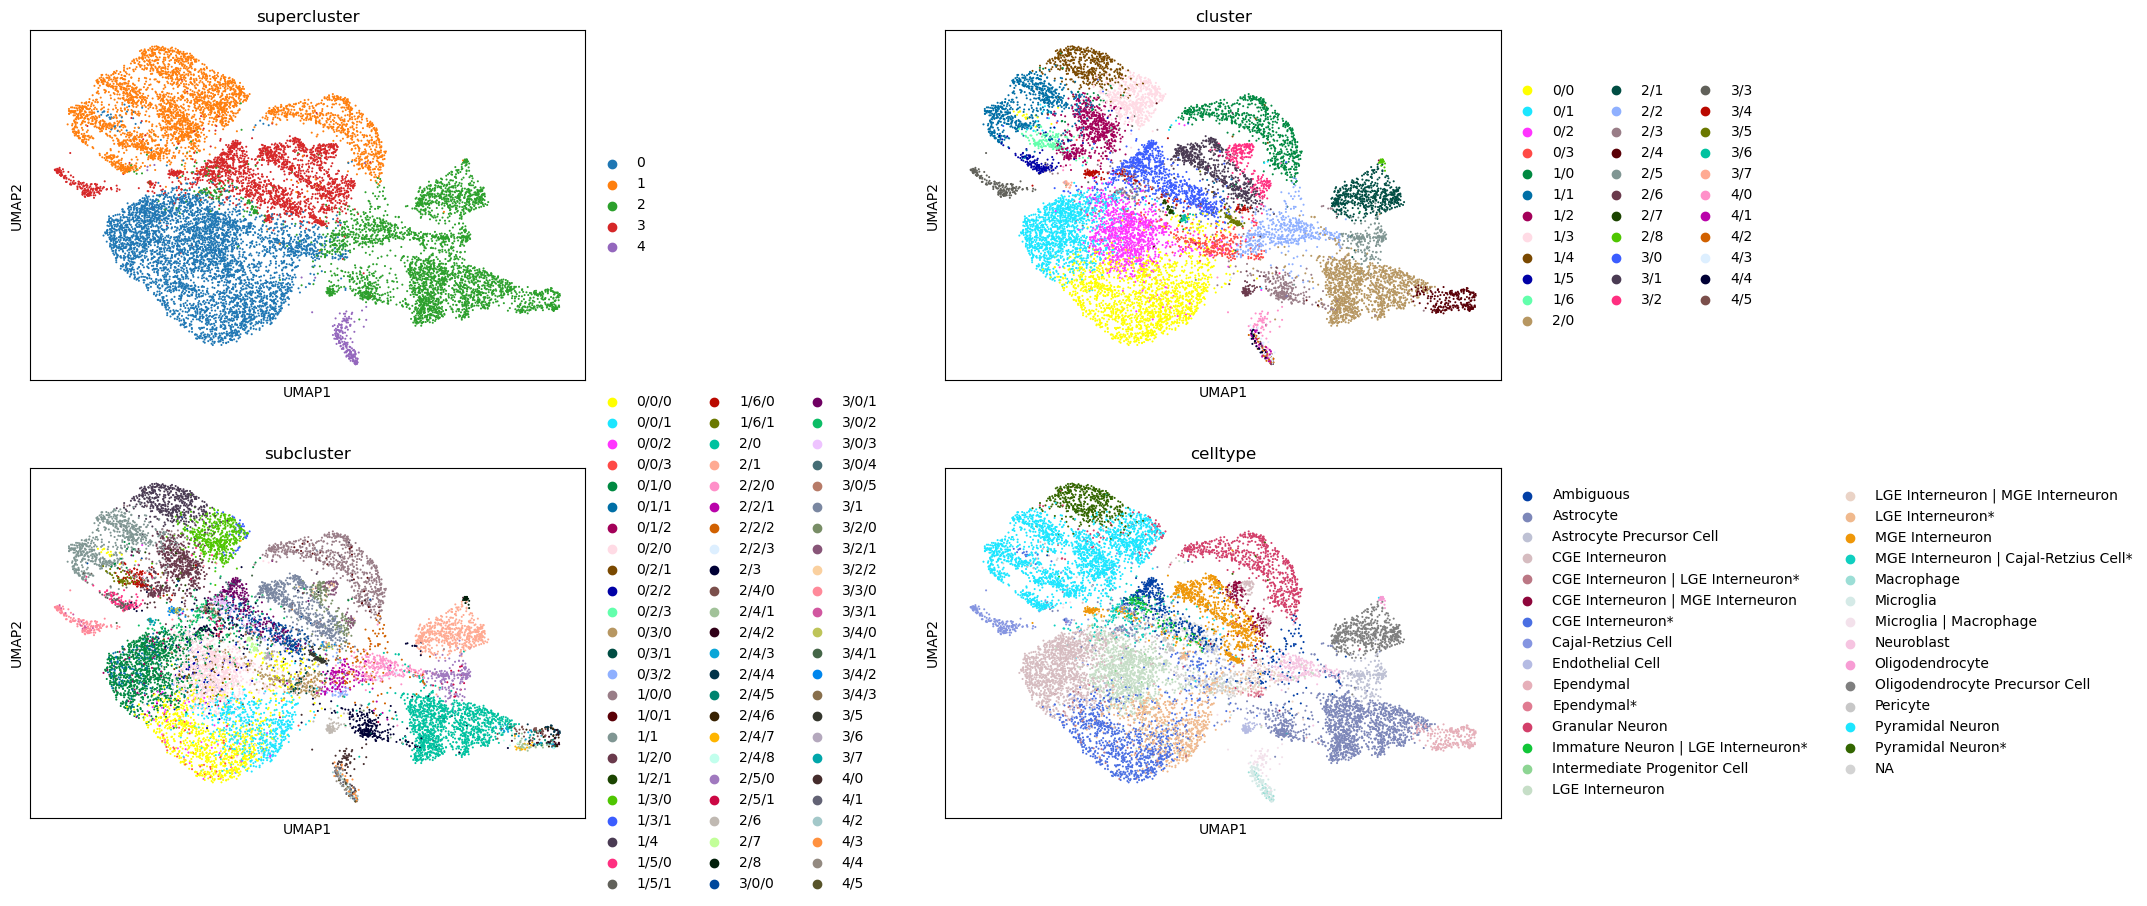

In [35]:
sc.pl.umap(adata, color=['supercluster', 'cluster', 'subcluster', 'celltype'], wspace=0.5, ncols=2)

In [36]:
# Save the updated adata with annotations
output_path = f"/home/ratopin/big_data/annotated/{region}_annotated.h5ad"
adata.write_h5ad(output_path)
print(f"Annotated adata saved to: {output_path}")

Annotated adata saved to: /home/ratopin/big_data/annotated/hippocampus_annotated.h5ad
